### CO2

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNRegressor  
from utils import eval, visual, save, save_model
import numpy as np
from sklearn.model_selection import KFold

In [2]:
import pandas as pd
data = pd.read_csv('data/compound_2_CO2.csv').iloc[:, 1:]

X = data.iloc[:, :-1] 
y = data.iloc[:, -1].astype(float) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

In [3]:
X_train = np.asarray(X_train, dtype=np.float32)
X_test  = np.asarray(X_test,  dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.float32).reshape(-1)
y_test  = np.asarray(y_test,  dtype=np.float32).reshape(-1)


In [4]:
def metrics(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae  = mean_absolute_error(y_true, y_pred)
    return r2, mae, rmse

def cv_score(X, y, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    r2s, maes, rmses = [], [], []
    for tr, va in kf.split(X):
        reg = TabPFNRegressor(device='cuda', model_path="tabpfn_models/tabpfn-v2-regressor.ckpt", n_estimators=64)
        reg.fit(X[tr], y[tr])
        pred = reg.predict(X[va])
        r2, mae, rmse = metrics(y[va], pred)
        r2s.append(r2); maes.append(mae); rmses.append(rmse)
    return (
        (np.mean(r2s),  np.std(r2s)),
        (np.mean(maes), np.std(maes)),
        (np.mean(rmses),np.std(rmses))
    )

In [5]:

regressor = TabPFNRegressor(device='cuda', model_path="tabpfn_models/tabpfn-v2-regressor.ckpt", n_estimators=64,random_state=42)  
regressor.fit(X_train, y_train)

train_pred = regressor.predict(X_train)
test_pred  = regressor.predict(X_test)

tr_r2, tr_mae, tr_rmse = metrics(y_train, train_pred)
te_r2, te_mae, te_rmse = metrics(y_test,  test_pred)

print("【Train】 R²={:.6f} | MAE={:.6f} | RMSE={:.6f}".format(tr_r2, tr_mae, tr_rmse))
print("【Test 】 R²={:.6f} | MAE={:.6f} | RMSE={:.6f}".format(te_r2, te_mae, te_rmse))

(cv_r2, cv_r2_std), (cv_mae, cv_mae_std), (cv_rmse, cv_rmse_std) = cv_score(X_train, y_train)
print("【CV-5】  R²={:.6f}±{:.6f} | MAE={:.6f}±{:.6f} | RMSE={:.6f}±{:.6f}".format(
    cv_r2, cv_r2_std, cv_mae, cv_mae_std, cv_rmse, cv_rmse_std
))


【Train】 R²=0.963959 | MAE=0.027156 | RMSE=0.068380
【Test 】 R²=0.894815 | MAE=0.058929 | RMSE=0.120240
【CV-5】  R²=0.906310±0.026560 | MAE=0.060263±0.006985 | RMSE=0.108267±0.018315


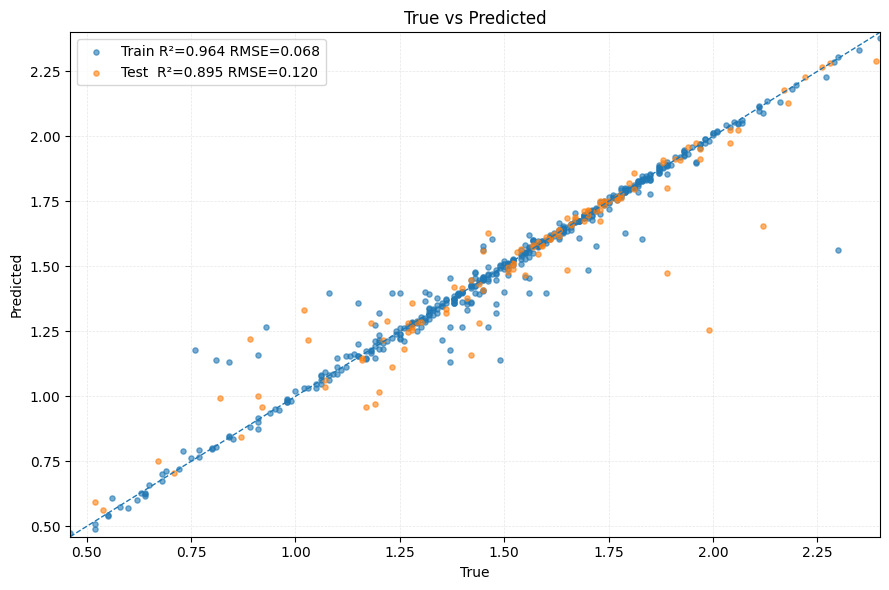

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

y_tr = np.asarray(y_train).ravel()
y_te = np.asarray(y_test).ravel()
p_tr = np.asarray(regressor.predict(X_train)).ravel()
p_te = np.asarray(regressor.predict(X_test)).ravel()

def r2_rmse(y, p):
    return r2_score(y, p), mean_squared_error(y, p, squared=False)

r2_tr, rmse_tr = r2_rmse(y_tr, p_tr)
r2_te, rmse_te = r2_rmse(y_te, p_te)

lo = float(min(y_tr.min(), y_te.min(), p_tr.min(), p_te.min()))
hi = float(max(y_tr.max(), y_te.max(), p_tr.max(), p_te.max()))

plt.figure(figsize=(9, 6))
plt.scatter(y_tr, p_tr, s=14, alpha=0.6, label=f"Train R²={r2_tr:.3f} RMSE={rmse_tr:.3f}")
plt.scatter(y_te, p_te, s=14, alpha=0.6, label=f"Test  R²={r2_te:.3f} RMSE={rmse_te:.3f}")
plt.plot([lo, hi], [lo, hi], '--', lw=1)  # y=x
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.xlabel("True"); plt.ylabel("Predicted")
plt.title("True vs Predicted")
plt.legend()
plt.grid(alpha=0.3, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [7]:
from pathlib import Path

df_train = pd.DataFrame({
    "split": "train",
    "row_id": np.arange(len(y_tr)),
    "y_true": y_tr,
    "y_pred": p_tr,
    "residual": y_tr - p_tr,
})
df_test = pd.DataFrame({
    "split": "test",
    "row_id": np.arange(len(y_te)),
    "y_true": y_te,
    "y_pred": p_te,
    "residual": y_te - p_te,
})
df_points = pd.concat([df_train, df_test], ignore_index=True)

out_path = Path("plots/TabPFN_CO2_2.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
df_points.to_csv(out_path, index=False)

print(f"Saved scatter points to: {out_path}  (rows={len(df_points)})")


Saved scatter points to: plots/TabPFN_CO2_2.csv  (rows=559)


In [8]:
import os, gc, time
import numpy as np
import pandas as pd
from tqdm import tqdm

df_new = pd.read_csv('data/compound_new_structural.csv')

CURRENT_DENSITY_VAL = 50
df_new["CurrentDensity"] = CURRENT_DENSITY_VAL
cols = [c for c in df_new.columns if c not in ("compound", "CurrentDensity")] + ["CurrentDensity"]
df_ordered = df_new[["compound"] + cols]

compounds = df_ordered['compound'].values
X_pred = df_ordered.drop(columns=['compound']).to_numpy(dtype=np.float32)

OUTER_BATCH = 2000

def _as_mean_array(out):
    if isinstance(out, dict):
        for k in ('mean', 'pred', 'prediction', 'preds'):
            if k in out:
                return np.asarray(out[k], dtype=np.float32).ravel()
        return np.asarray(out, dtype=np.float32).ravel()
    return np.asarray(out, dtype=np.float32).ravel()

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

try:
    import torch
    HAS_TORCH = torch.cuda.is_available()
except Exception:
    HAS_TORCH = False

def predict_with_microchunks(Xb, start_idx, preds,
                             init_micro=512, min_micro=1):

    n = len(Xb)
    done = 0
    micro = init_micro

    while done < n:
        end = min(done + micro, n)
        try:
            out = regressor.predict(Xb[done:end], output_type='main')
            mu = _as_mean_array(out)
            preds[start_idx + done : start_idx + end] = mu[:(end - done)]

            done = end

            # 释放无用对象并清显存
            if HAS_TORCH:
                try:
                    torch.cuda.synchronize()
                    torch.cuda.empty_cache()
                except Exception:
                    pass
            del out, mu
            gc.collect()
            time.sleep(0.002)

        except RuntimeError as e:
            msg = str(e).lower()
            if ('out of memory' in msg or 'cuda' in msg) and micro > min_micro:
                micro = max(min_micro, micro // 2)
                print(f"[OOM] inner micro-batch -> {micro}")
                if HAS_TORCH:
                    try:
                        torch.cuda.synchronize()
                        torch.cuda.empty_cache()
                    except Exception:
                        pass
                gc.collect()
                time.sleep(0.02)
            else:
                raise

n = len(X_pred)
preds = np.empty(n, dtype=np.float32)
print(f"[Info] pool size={n}, n_features={X_pred.shape[1]}, outer_batch={OUTER_BATCH}")

pbar = tqdm(total=n, desc="predict mean (TabPFN)", unit="row")

for i in range(0, n, OUTER_BATCH):
    end = min(i + OUTER_BATCH, n)
    Xb = X_pred[i:end]
    predict_with_microchunks(Xb, start_idx=i, preds=preds, init_micro=512, min_micro=1)
    pbar.update(end - i)

    if HAS_TORCH:
        try:
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
        except Exception:
            pass
    del Xb
    gc.collect()

pbar.close()

os.makedirs('predict', exist_ok=True)
pd.DataFrame({
    'compound': compounds,
    'predicted_mean': preds
}).to_csv('predict/tabpfn_predict_CO2_2_50.csv', index=False)

print("✅ saved 'predict/tabpfn_predict_CO2_2_50.csv'")


[Info] pool size=34005, n_features=34, outer_batch=2000


predict mean (TabPFN): 100%|██████████| 34005/34005 [03:04<00:00, 184.58row/s]

✅ saved 'predict/tabpfn_predict_CO2_2_50.csv'


### O2

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNRegressor  
from utils import eval, visual, save, save_model
import numpy as np
from sklearn.model_selection import KFold

In [2]:
import pandas as pd
data = pd.read_csv('data/compound_2_O2.csv').iloc[:, 1:]

X = data.iloc[:, :-1]  
y = data.iloc[:, -1].astype(float)  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
X_train = np.asarray(X_train, dtype=np.float32)
X_test  = np.asarray(X_test,  dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.float32).reshape(-1)
y_test  = np.asarray(y_test,  dtype=np.float32).reshape(-1)

In [4]:
def metrics(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae  = mean_absolute_error(y_true, y_pred)
    return r2, mae, rmse

def cv_score(X, y, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    r2s, maes, rmses = [], [], []
    for tr, va in kf.split(X):
        reg = TabPFNRegressor(device='cuda', model_path="tabpfn_models/tabpfn-v2-regressor.ckpt", n_estimators=64)
        reg.fit(X[tr], y[tr])
        pred = reg.predict(X[va])
        r2, mae, rmse = metrics(y[va], pred)
        r2s.append(r2); maes.append(mae); rmses.append(rmse)
    return (
        (np.mean(r2s),  np.std(r2s)),
        (np.mean(maes), np.std(maes)),
        (np.mean(rmses),np.std(rmses))
    )

In [5]:

regressor = TabPFNRegressor(device='cuda', model_path="tabpfn_models/tabpfn-v2-regressor.ckpt", n_estimators=64,random_state=42)  
regressor.fit(X_train, y_train)

train_pred = regressor.predict(X_train)
test_pred  = regressor.predict(X_test)

tr_r2, tr_mae, tr_rmse = metrics(y_train, train_pred)
te_r2, te_mae, te_rmse = metrics(y_test,  test_pred)

print("【Train】 R²={:.6f} | MAE={:.6f} | RMSE={:.6f}".format(tr_r2, tr_mae, tr_rmse))
print("【Test 】 R²={:.6f} | MAE={:.6f} | RMSE={:.6f}".format(te_r2, te_mae, te_rmse))

(cv_r2, cv_r2_std), (cv_mae, cv_mae_std), (cv_rmse, cv_rmse_std) = cv_score(X_train, y_train)
print("【CV-5】  R²={:.6f}±{:.6f} | MAE={:.6f}±{:.6f} | RMSE={:.6f}±{:.6f}".format(
    cv_r2, cv_r2_std, cv_mae, cv_mae_std, cv_rmse, cv_rmse_std
))


【Train】 R²=0.908317 | MAE=0.025627 | RMSE=0.061814
【Test 】 R²=0.525844 | MAE=0.063584 | RMSE=0.174728
【CV-5】  R²=0.614594±0.248497 | MAE=0.065907±0.034555 | RMSE=0.120930±0.058609


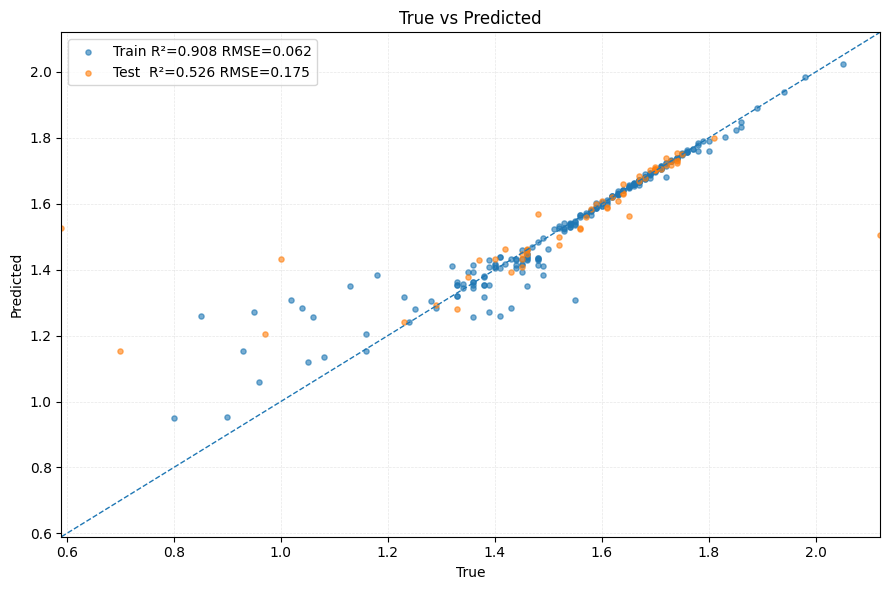

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

y_tr = np.asarray(y_train).ravel()
y_te = np.asarray(y_test).ravel()
p_tr = np.asarray(regressor.predict(X_train)).ravel()
p_te = np.asarray(regressor.predict(X_test)).ravel()

def r2_rmse(y, p):
    return r2_score(y, p), mean_squared_error(y, p, squared=False)

r2_tr, rmse_tr = r2_rmse(y_tr, p_tr)
r2_te, rmse_te = r2_rmse(y_te, p_te)

lo = float(min(y_tr.min(), y_te.min(), p_tr.min(), p_te.min()))
hi = float(max(y_tr.max(), y_te.max(), p_tr.max(), p_te.max()))

plt.figure(figsize=(9, 6))
plt.scatter(y_tr, p_tr, s=14, alpha=0.6, label=f"Train R²={r2_tr:.3f} RMSE={rmse_tr:.3f}")
plt.scatter(y_te, p_te, s=14, alpha=0.6, label=f"Test  R²={r2_te:.3f} RMSE={rmse_te:.3f}")
plt.plot([lo, hi], [lo, hi], '--', lw=1)  # y=x
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.xlabel("True"); plt.ylabel("Predicted")
plt.title("True vs Predicted")
plt.legend()
plt.grid(alpha=0.3, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [7]:
# === Save scatter points for external plotting ===
from pathlib import Path

df_train = pd.DataFrame({
    "split": "train",
    "row_id": np.arange(len(y_tr)),
    "y_true": y_tr,
    "y_pred": p_tr,
    "residual": y_tr - p_tr,
})
df_test = pd.DataFrame({
    "split": "test",
    "row_id": np.arange(len(y_te)),
    "y_true": y_te,
    "y_pred": p_te,
    "residual": y_te - p_te,
})
df_points = pd.concat([df_train, df_test], ignore_index=True)

out_path = Path("plots/TabPFN_O2_2.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
df_points.to_csv(out_path, index=False)

print(f"Saved scatter points to: {out_path}  (rows={len(df_points)})")


Saved scatter points to: plots/TabPFN_O2_2.csv  (rows=284)


In [8]:
import os, gc, time
import numpy as np
import pandas as pd
from tqdm import tqdm

df_new = pd.read_csv('data/compound_new_structural.csv')

CURRENT_DENSITY_VAL = 50
df_new["CurrentDensity"] = CURRENT_DENSITY_VAL
cols = [c for c in df_new.columns if c not in ("compound", "CurrentDensity")] + ["CurrentDensity"]
df_ordered = df_new[["compound"] + cols]

compounds = df_ordered['compound'].values
X_pred = df_ordered.drop(columns=['compound']).to_numpy(dtype=np.float32)

OUTER_BATCH = 2000

def _as_mean_array(out):
    if isinstance(out, dict):
        for k in ('mean', 'pred', 'prediction', 'preds'):
            if k in out:
                return np.asarray(out[k], dtype=np.float32).ravel()
        return np.asarray(out, dtype=np.float32).ravel()
    return np.asarray(out, dtype=np.float32).ravel()

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

try:
    import torch
    HAS_TORCH = torch.cuda.is_available()
except Exception:
    HAS_TORCH = False

def predict_with_microchunks(Xb, start_idx, preds,
                             init_micro=512, min_micro=1):

    n = len(Xb)
    done = 0
    micro = init_micro

    while done < n:
        end = min(done + micro, n)
        try:
            out = regressor.predict(Xb[done:end], output_type='main')
            mu = _as_mean_array(out)
            preds[start_idx + done : start_idx + end] = mu[:(end - done)]

            done = end

            if HAS_TORCH:
                try:
                    torch.cuda.synchronize()
                    torch.cuda.empty_cache()
                except Exception:
                    pass
            del out, mu
            gc.collect()
            time.sleep(0.002)

        except RuntimeError as e:
            msg = str(e).lower()
            if ('out of memory' in msg or 'cuda' in msg) and micro > min_micro:
                micro = max(min_micro, micro // 2)
                print(f"[OOM] inner micro-batch -> {micro}")
                if HAS_TORCH:
                    try:
                        torch.cuda.synchronize()
                        torch.cuda.empty_cache()
                    except Exception:
                        pass
                gc.collect()
                time.sleep(0.02)
            else:
                raise

n = len(X_pred)
preds = np.empty(n, dtype=np.float32)
print(f"[Info] pool size={n}, n_features={X_pred.shape[1]}, outer_batch={OUTER_BATCH}")

pbar = tqdm(total=n, desc="predict mean (TabPFN)", unit="row")

for i in range(0, n, OUTER_BATCH):
    end = min(i + OUTER_BATCH, n)
    Xb = X_pred[i:end]
    predict_with_microchunks(Xb, start_idx=i, preds=preds, init_micro=512, min_micro=1)
    pbar.update(end - i)

    if HAS_TORCH:
        try:
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
        except Exception:
            pass
    del Xb
    gc.collect()

pbar.close()

os.makedirs('predict', exist_ok=True)
pd.DataFrame({
    'compound': compounds,
    'predicted_mean': preds
}).to_csv('predict/tabpfn_predict_O2_2_50.csv', index=False)

print("✅ saved 'predict/tabpfn_predict_O2_2_50.csv'")


[Info] pool size=34005, n_features=34, outer_batch=2000


predict mean (TabPFN): 100%|██████████| 34005/34005 [02:43<00:00, 207.87row/s]

✅ saved 'predict/tabpfn_predict_O2_2_50.csv'
